Lets make a machine learning model that predict the price of house,
This dataset contains real estate information in the Philippines as of 2024/03/20. It includes the description, location, prices, number of bedrooms and bathrooms, floor and land area, and geographical coordinates.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split    
from sklearn.linear_model import LinearRegression
#load the data

df = pd.read_csv('Housing_v2.csv')


In [ ]:
df

In [5]:
df_clean = df.copy()

In [6]:
columns = [
    'Price',
    'Bedrooms',
    'Bathrooms',
    'Floor Area',
    'Land Area',
]

df_clean = df_clean[columns]


<Axes: xlabel='Price', ylabel='Density'>

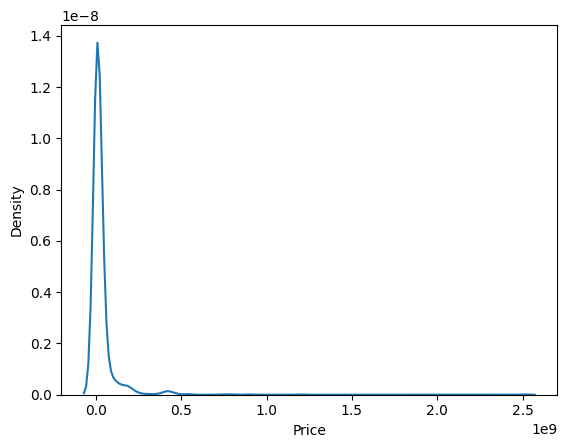

In [7]:
sns.kdeplot(data=df_clean, x='Price')

In [ ]:
df_clean['Price'].skew()

np.float64(13.072721009026449)

In [9]:
num_cols = [
    'Price',
    'Bedrooms',
    'Bathrooms',
    'Floor Area',
    'Land Area'
]

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].mean())                    

In [23]:
#Remove the Outliers of the Price
Q1 = df_clean['Price'].quantile(0.25)
Q3 = df_clean['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[
    (df_clean['Price'] >= lower_bound) &
    (df_clean['Price'] <= upper_bound)
]

df_clean['Price_log'] = np.log1p(df_clean['Price'])

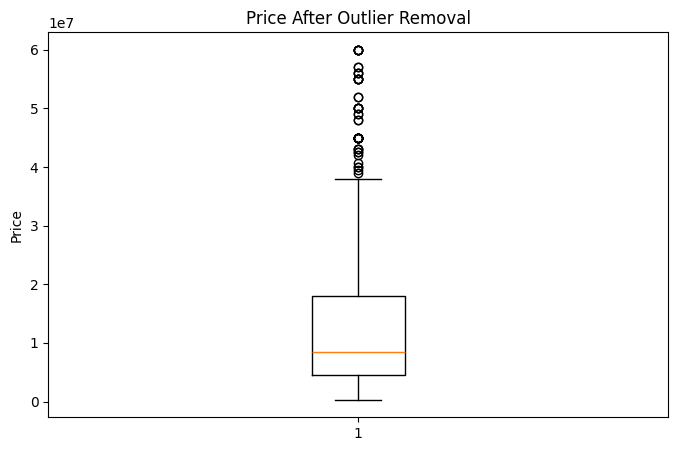

In [24]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean['Price'])
plt.ylabel("Price")
plt.title("Price After Outlier Removal")
plt.show()

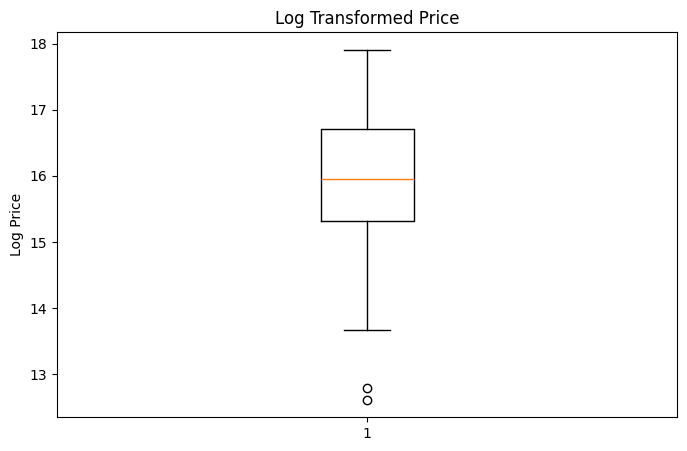

In [7]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean['Price_log'])
plt.ylabel("Log Price")
plt.title("Log Transformed Price")
plt.show()

In [ ]:
features = ['Bedrooms', 'Bathrooms', 'Floor Area', 'Land Area']

for col in features:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_clean[col])
    plt.ylabel(col)
    plt.title(f"{col} Boxplot")
    plt.show()

In [25]:
X = df_clean[
    ['Bedrooms', 'Bathrooms', 'Floor Area', 'Land Area']
]

y = df_clean['Price_log']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.16,0.06,0. ,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Bedrooms','Bathrooms','Floor Area','Land Area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,14.72
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [28]:
y_pred = model.predict(X_test)

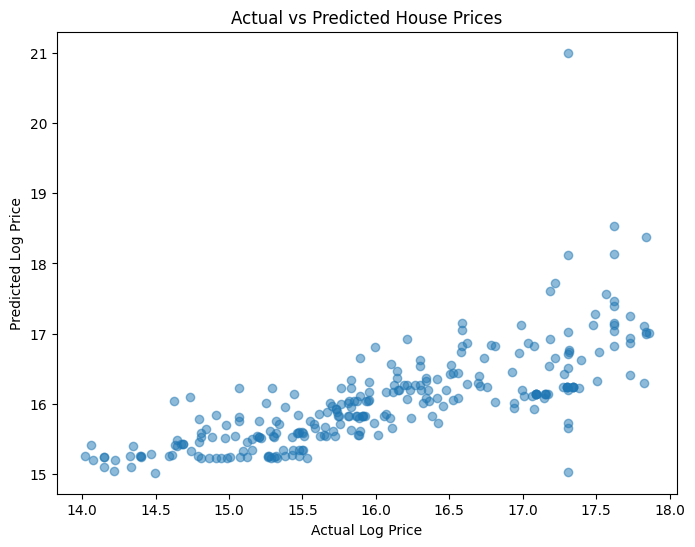

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [30]:
new_house = pd.DataFrame({
    'Bedrooms': [2],
    'Bathrooms': [1],
    'Floor Area': [16],
    'Land Area': [20],
})

predicted_log_price = model.predict(new_house)

predicted_price = np.expm1(predicted_log_price)

print(f"Predicted Price: ${predicted_price[0]:,.2f}")

Predicted Price: $3,806,330.15


In [32]:
from sklearn.metrics import r2_score


r2 = r2_score(y_test, y_pred)

print(f"R-squared: {r2:.4f}")

R-squared: 0.5505


This project used Linear Regression to predict residential property prices in the Philippines. The dataset was cleaned by handling missing values and reducing outliers using the IQR method. Since house prices were highly skewed, log transformation was applied to the target variable. The model was evaluated using R² Score.The results show that property features such as bedrooms, bathrooms, floor area, land area, latitude, and longitude can help estimate house prices.